# Modelado Mecanístico No Lineal de una Red Regulatoria Biestable

### Sistema de retroalimentación positiva doble (Toggle Switch)

Este cuaderno construye, **desde cero**, un modelo mecanístico de EDOs no lineales para la red regulatoria mostrada en la figura. Seguimos la metodología de **8 pasos**:

1. Representaciones visuales de la red
2. Representación matemática (EDOs)
3. Simplificación por conservación
4. Condiciones iniciales y parámetros
5. Análisis de estado estacionario
6. Simulación dinámica
7. Optimización de parámetros
8. Análisis de robustez (bifurcación y planos de fase)

**Sistema biológico:** Red de dos componentes ($X_1$, $Y_1$) con precursores inactivos ($X_2$, $Y_2$), donde cada componente inhibe al otro mediante retroalimentación positiva sigmoidal (Hill). Este tipo de red es fundamental en decisiones celulares (diferenciación, apoptosis, ciclo celular).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import fsolve, minimize
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

# Paso 1: Representación Visual de la Red de Reacción

## Arquitectura del sistema

La red consta de **dos módulos acoplados** que se inhiben mutuamente:

### Módulo X (rojo)
- **$X_2$ → $X_1$**: conversión del precursor $X_2$ a la forma activa $X_1$, con tasa base $\alpha_1$.
- **$X_1$ → $X_2$**: regreso a la forma inactiva, con tasa $\beta_1$. Esta reacción está **modulada por $Y_1$** mediante una función sigmoidal (Hill).

### Módulo Y (azul)
- **$Y_2$ → $Y_1$**: conversión del precursor $Y_2$ a la forma activa $Y_1$, con tasa base $\alpha_2$.
- **$Y_1$ → $Y_2$**: regreso a la forma inactiva, con tasa $\beta_2$. Esta reacción está **modulada por $X_1$** con Hill.

### Acoplamiento cruzado
- $Y_1$ **inhibe** $X_1$ (al promover su degradación $X_1 \to X_2$).
- $X_1$ **inhibe** $Y_1$ (al promover su degradación $Y_1 \to Y_2$).

Esto produce una **doble retroalimentación positiva** que genera **biestabilidad**.

## Moduladores externos (EC)
Los cuadros EC (*External Conditions*) sobre los módulos representan factores externos que modulan los parámetros efectivos $\alpha_i, \beta_i, K_i, \gamma_i$ y en particular $\nu$ (fuerza del acoplamiento $Y_1 \to X_1$).

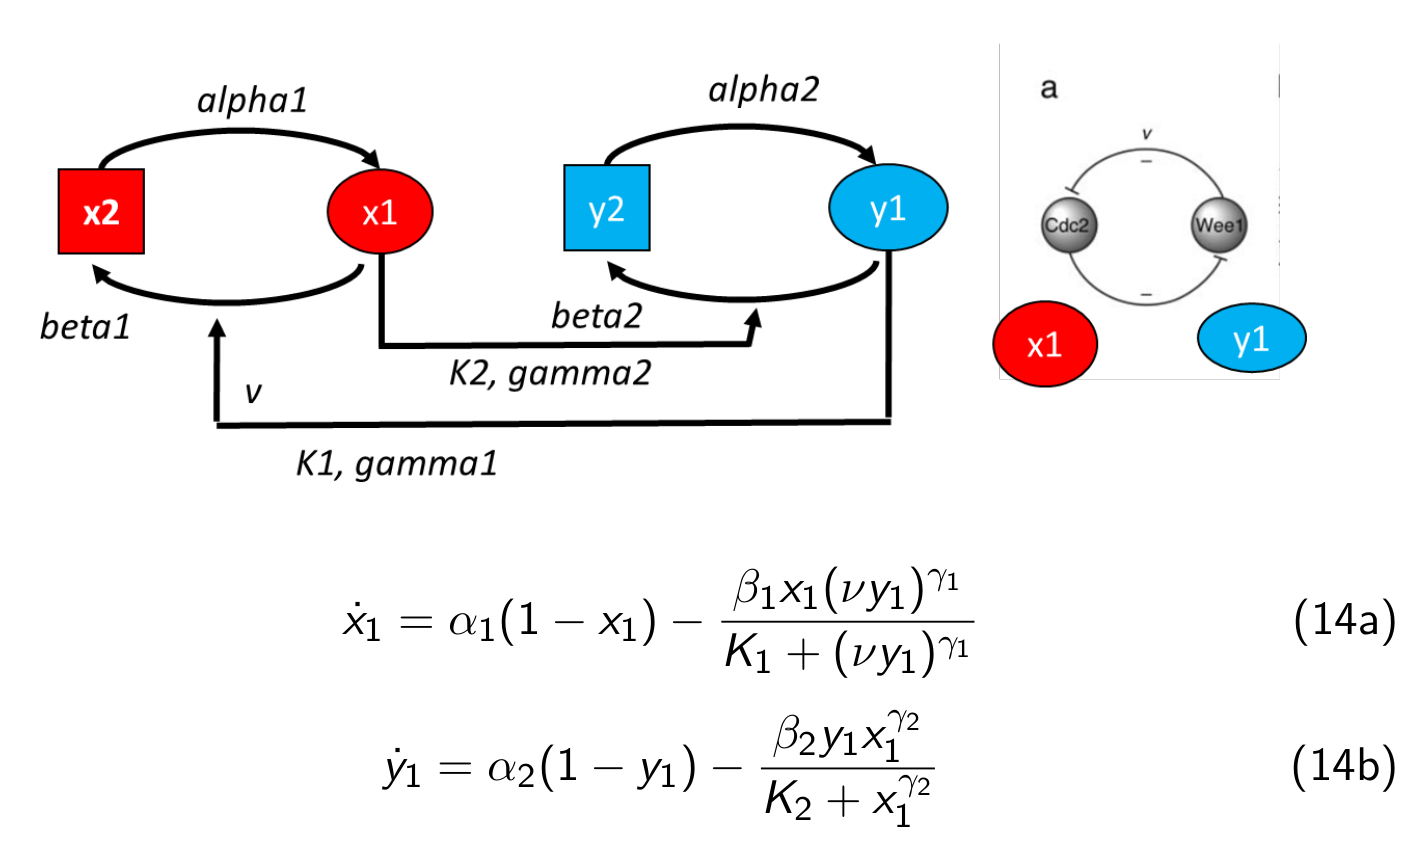

# Paso 2: Representación Matemática del Sistema

## Ley de Acción de Masas + Cinética de Hill

### Términos de reacción

**Producción de $X_1$ (orden 1 respecto a su precursor):**
$$v_{\text{prod}}^{(X)} = \alpha_1 \, X_2$$

**Degradación de $X_1$ modulada por $Y_1$ (Hill):**
$$v_{\text{deg}}^{(X)} = \frac{\beta_1 \, X_1 \, (\nu Y_1)^{\gamma_1}}{K_1 + (\nu Y_1)^{\gamma_1}}$$

**Producción de $Y_1$:**
$$v_{\text{prod}}^{(Y)} = \alpha_2 \, Y_2$$

**Degradación de $Y_1$ modulada por $X_1$ (Hill):**
$$v_{\text{deg}}^{(Y)} = \frac{\beta_2 \, Y_1 \, X_1^{\gamma_2}}{K_2 + X_1^{\gamma_2}}$$

### Sistema completo de EDOs (4 dimensiones)

$$
\begin{aligned}
\dot{X}_1 &= \alpha_1 X_2 - \frac{\beta_1 X_1 (\nu Y_1)^{\gamma_1}}{K_1 + (\nu Y_1)^{\gamma_1}} \\[4pt]
\dot{X}_2 &= -\alpha_1 X_2 + \frac{\beta_1 X_1 (\nu Y_1)^{\gamma_1}}{K_1 + (\nu Y_1)^{\gamma_1}} \\[4pt]
\dot{Y}_1 &= \alpha_2 Y_2 - \frac{\beta_2 Y_1 X_1^{\gamma_2}}{K_2 + X_1^{\gamma_2}} \\[4pt]
\dot{Y}_2 &= -\alpha_2 Y_2 + \frac{\beta_2 Y_1 X_1^{\gamma_2}}{K_2 + X_1^{\gamma_2}}
\end{aligned}
$$

## Interpretación de la cooperatividad (Hill)

- **$K_1, K_2$**: constante de disociación efectiva (concentración del modulador a la que la respuesta alcanza la mitad de su velocidad máxima).
- **$\gamma_1, \gamma_2$**: exponente de Hill. Cuando $\gamma > 1$ aparece una respuesta **sigmoidal** (cooperatividad positiva).
- **$\nu$**: factor de escala que modula la "fuerza" efectiva de $Y_1$ sobre $X_1$. Es el parámetro que controlaremos en el análisis de bifurcación.

# Paso 3: Simplificación por Ecuaciones de Conservación

## Derivación

Las cantidades totales se conservan (no hay síntesis *de novo* ni degradación total):

$$X_1(t) + X_2(t) = C_X = \text{constante}$$
$$Y_1(t) + Y_2(t) = C_Y = \text{constante}$$

**Normalización**: sin pérdida de generalidad, tomamos $C_X = C_Y = 1$ (esto es lo que significa la nota *"$X_1 + X_2$ es una $K$, particularmente 1"* de la figura):

$$X_1 + X_2 = 1 \quad\Longrightarrow\quad X_2 = 1 - X_1$$
$$Y_1 + Y_2 = 1 \quad\Longrightarrow\quad Y_2 = 1 - Y_1$$

## Verificación algebraica

$$\frac{d(X_1 + X_2)}{dt} = \dot{X}_1 + \dot{X}_2 = \left[\alpha_1 X_2 - v_{\text{deg}}^{(X)}\right] + \left[v_{\text{deg}}^{(X)} - \alpha_1 X_2\right] = 0 \;\checkmark$$

## Sistema reducido (2 dimensiones) — Ecs. 13a y 13b

$$\boxed{\;\dot{x}_1 = \alpha_1 (1 - x_1) - \frac{\beta_1 \, x_1 (\nu y_1)^{\gamma_1}}{K_1 + (\nu y_1)^{\gamma_1}}\;}$$

$$\boxed{\;\dot{y}_1 = \alpha_2 (1 - y_1) - \frac{\beta_2 \, y_1 \, x_1^{\gamma_2}}{K_2 + x_1^{\gamma_2}}\;}$$

**Ventaja computacional:** pasamos de 4 EDOs a 2 EDOs. Esto reduce el costo computacional en análisis de bifurcación y espacio de fases.

# Paso 4: Condiciones Iniciales, Parámetros y Comportamientos Cualitativos

## Condiciones iniciales
$$x_1(0), \; y_1(0) \in [0, 1]$$

## Tabla de parámetros

| Símbolo | Significado | Rango explorado |
|---|---|---|
| $\alpha_1, \alpha_2$ | Tasa de producción basal | 0.1 – 2.0 |
| $\beta_1, \beta_2$ | Tasa máxima de degradación | 0.5 – 10 |
| $K_1, K_2$ | Constante de Hill (afinidad) | 0.05 – 1.0 |
| $\gamma_1, \gamma_2$ | Exponente de Hill (cooperatividad) | 1 – 8 |
| $\nu$ | Escala del acoplamiento $Y_1 \to X_1$ | 0.1 – 3.0 |

## Comportamientos cualitativos a reproducir

1. **Biestabilidad**: dos atractores coexistiendo con la misma parametrización.
2. **Dependencia de condiciones iniciales**: el estado final depende del pasado (histéresis).
3. **Transición de fase** conforme $\nu$ cambia: de monostable a biestable y viceversa.

## Variables del sistema

- $x_1(t)$: concentración normalizada de la proteína activa X1.
- $y_1(t)$: concentración normalizada de la proteína activa Y1.

In [2]:
def model(state, t, p):
    """
    Sistema reducido 2D (Ecs. 13a, 13b).
    
    Parámetros (diccionario p):
      alpha1, alpha2, beta1, beta2, K1, K2, gamma1, gamma2, v
    """
    x1, y1 = state
    # Clip para evitar overflow numérico en potencias con exponentes grandes
    x1 = np.clip(x1, 1e-9, 1 - 1e-9)
    y1 = np.clip(y1, 1e-9, 1 - 1e-9)
    
    # Términos de Hill
    vy1 = p['v'] * y1
    num1 = vy1 ** p['gamma1']
    den1 = p['K1'] + num1
    hill1 = num1 / den1 if den1 > 0 else 0.0
    
    num2 = x1 ** p['gamma2']
    den2 = p['K2'] + num2
    hill2 = num2 / den2 if den2 > 0 else 0.0
    
    # EDOs
    dx1dt = p['alpha1'] * (1 - x1) - p['beta1'] * x1 * hill1
    dy1dt = p['alpha2'] * (1 - y1) - p['beta2'] * y1 * hill2
    
    return [dx1dt, dy1dt]


def simulate(p, x0, y0, t_max=20, n_points=2000):
    """Integra el sistema desde (x0, y0) hasta t_max."""
    t = np.linspace(0, t_max, n_points)
    sol = odeint(model, [x0, y0], t, args=(p,), hmax=0.05)
    return t, sol[:, 0], sol[:, 1]


# Parámetros por defecto (calibrados para reproducir la Fig. 3)
P_DEFAULT = {
    'alpha1': 0.5, 'alpha2': 0.5,
    'beta1': 5.0, 'beta2': 5.0,
    'K1': 0.5, 'K2': 0.5,
    'gamma1': 4.0, 'gamma2': 4.0,
    'v': 1.0
}

# Test rápido
t, x1, y1 = simulate(P_DEFAULT, 0.0, 0.0)
print(f"Estado final desde (0,0): x1={x1[-1]:.4f}, y1={y1[-1]:.4f}")
t, x1, y1 = simulate(P_DEFAULT, 0.9, 0.9)
print(f"Estado final desde (0.9,0.9): x1={x1[-1]:.4f}, y1={y1[-1]:.4f}")

Estado final desde (0,0): x1=0.4906, y1=0.4906
Estado final desde (0.9,0.9): x1=0.4906, y1=0.4906


In [ ]:
def explorar_parametros(alpha1, alpha2, beta1, beta2, K1, K2, gamma1, gamma2, v):
    p = {'alpha1': alpha1, 'alpha2': alpha2,
         'beta1': beta1, 'beta2': beta2,
         'K1': K1, 'K2': K2,
         'gamma1': gamma1, 'gamma2': gamma2, 'v': v}
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    
    # --- Panel 1: Dinámica temporal de y1 desde dos condiciones iniciales ---
    t, x1a, y1a = simulate(p, 0.0, 0.0, t_max=20)
    t, x1b, y1b = simulate(p, 0.0, 0.9, t_max=20)
    
    axes[0].plot(t, y1a, color='k', lw=2, label=r'$y_0 = [0,\;0]$')
    axes[0].plot(t, y1b, color='red', lw=2, label=r'$y_0 = [0,\;0.9]$')
    axes[0].plot([t[-1]], [y1a[-1]], 'ko', ms=8)
    axes[0].plot([t[-1]], [y1b[-1]], 'ro', ms=8)
    axes[0].set_xlabel('t'); axes[0].set_ylabel(r'$y_1(t)$')
    axes[0].set_title(rf'Dinámica de $y_1$, $\nu = {v:.2f}$')
    axes[0].set_ylim(-0.02, 1.02); axes[0].set_xlim(0, 20)
    axes[0].legend(loc='best')
    
    # --- Panel 2: Plano de fase con campo vectorial ---
    ngrid = 25
    X1, Y1 = np.meshgrid(np.linspace(0, 1, ngrid), np.linspace(0, 1, ngrid))
    U = np.zeros_like(X1); V = np.zeros_like(Y1)
    for i in range(ngrid):
        for j in range(ngrid):
            dx, dy = model([X1[i, j], Y1[i, j]], 0, p)
            U[i, j] = dx; V[i, j] = dy
    # Normalizar flechas
    N = np.sqrt(U**2 + V**2) + 1e-12
    Un, Vn = U / N, V / N
    
    axes[1].quiver(X1, Y1, Un, Vn, color='blue', alpha=0.55, 
                   scale=25, width=0.003, headwidth=3)
    
    # Nullclines: dx1/dt = 0 (negro) y dy1/dt = 0 (gris)
    xg = np.linspace(0.001, 0.999, 400)
    yg = np.linspace(0.001, 0.999, 400)
    XG, YG = np.meshgrid(xg, yg)
    DX = np.zeros_like(XG); DY = np.zeros_like(XG)
    for i in range(XG.shape[0]):
        for j in range(XG.shape[1]):
            dx, dy = model([XG[i, j], YG[i, j]], 0, p)
            DX[i, j] = dx; DY[i, j] = dy
    axes[1].contour(XG, YG, DX, levels=[0], colors='black', linewidths=1.8)
    axes[1].contour(XG, YG, DY, levels=[0], colors='gray', linewidths=1.8, linestyles='--')
    
    # Trayectoria desde (0,0)
    axes[1].plot(x1a, y1a, color='k', lw=2.5)
    axes[1].plot(x1a[-1], y1a[-1], 'ko', ms=9)
    
    axes[1].set_xlabel(r'$x_1(t)$'); axes[1].set_ylabel(r'$y_1(t)$')
    axes[1].set_title(rf'Diagrama de fase, $\nu = {v:.2f}$')
    axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()


widgets.interact(explorar_parametros,
    alpha1=widgets.FloatSlider(value=0.5, min=0.1, max=2, step=0.05, description=r'$\alpha_1$:'),
    alpha2=widgets.FloatSlider(value=0.5, min=0.1, max=2, step=0.05, description=r'$\alpha_2$:'),
    beta1=widgets.FloatSlider(value=5.0, min=0.5, max=10, step=0.1, description=r'$\beta_1$:'),
    beta2=widgets.FloatSlider(value=5.0, min=0.5, max=10, step=0.1, description=r'$\beta_2$:'),
    K1=widgets.FloatSlider(value=0.5, min=0.05, max=1.0, step=0.05, description=r'$K_1$:'),
    K2=widgets.FloatSlider(value=0.5, min=0.05, max=1.0, step=0.05, description=r'$K_2$:'),
    gamma1=widgets.FloatSlider(value=4.0, min=1, max=8, step=0.5, description=r'$\gamma_1$:'),
    gamma2=widgets.FloatSlider(value=4.0, min=1, max=8, step=0.5, description=r'$\gamma_2$:'),
    v=widgets.FloatSlider(value=1.0, min=0.1, max=3.0, step=0.05, description=r'$\nu$:')
)

interactive(children=(FloatSlider(value=0.5, description='$\\alpha_1$:', max=2.0, min=0.1, step=0.05), FloatSl…

<function __main__.explorar_parametros(alpha1, alpha2, beta1, beta2, K1, K2, gamma1, gamma2, v)>

# Paso 5: Análisis de Estado Estacionario

## Ecuaciones de equilibrio

En el estado estacionario, $\dot{x}_1 = \dot{y}_1 = 0$, lo que da el sistema algebraico no lineal:

$$\alpha_1 (1 - x_1^*) = \frac{\beta_1 \, x_1^* (\nu y_1^*)^{\gamma_1}}{K_1 + (\nu y_1^*)^{\gamma_1}} \quad (N_X)$$

$$\alpha_2 (1 - y_1^*) = \frac{\beta_2 \, y_1^* (x_1^*)^{\gamma_2}}{K_2 + (x_1^*)^{\gamma_2}} \quad (N_Y)$$

## Curvas nulas (nullclines)

Despejando $y_1$ de $(N_X)$:

$$y_1^{(X)}(x_1) = \frac{1}{\nu}\left[\frac{K_1 \, \alpha_1 (1 - x_1)}{\beta_1 x_1 - \alpha_1 (1 - x_1)}\right]^{1/\gamma_1}$$

Despejando $y_1$ de $(N_Y)$:

$$y_1^{(Y)}(x_1) = \frac{\alpha_2}{\alpha_2 + \frac{\beta_2 x_1^{\gamma_2}}{K_2 + x_1^{\gamma_2}}}$$

## Puntos fijos y estabilidad

Las **intersecciones** de las dos nullclines son los puntos fijos. La estabilidad se determina por el Jacobiano:

$$J = \begin{pmatrix} \dfrac{\partial \dot{x}_1}{\partial x_1} & \dfrac{\partial \dot{x}_1}{\partial y_1} \\[6pt] \dfrac{\partial \dot{y}_1}{\partial x_1} & \dfrac{\partial \dot{y}_1}{\partial y_1} \end{pmatrix}$$

Un punto fijo es **estable** si $\text{tr}(J) < 0$ y $\det(J) > 0$. Si hay dos atractores estables, el sistema es **biestable**.

In [4]:
def nullcline_X(x1, p):
    """y1 como función de x1 a lo largo de dx1/dt=0."""
    x1 = np.clip(x1, 1e-9, 1-1e-9)
    num = p['K1'] * p['alpha1'] * (1 - x1)
    den = p['beta1'] * x1 - p['alpha1'] * (1 - x1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = np.where(den > 0, num / np.maximum(den, 1e-12), np.nan)
        y1 = (1 / p['v']) * ratio ** (1 / p['gamma1'])
    return y1


def nullcline_Y(x1, p):
    """y1 como función de x1 a lo largo de dy1/dt=0."""
    x1 = np.clip(x1, 1e-9, 1-1e-9)
    num = p['alpha2']
    den = p['alpha2'] + p['beta2'] * x1**p['gamma2'] / (p['K2'] + x1**p['gamma2'])
    return num / den


def find_fixed_points(p):
    """Encuentra todos los puntos fijos en [0,1]^2."""
    def residual(z):
        return model(z, 0, p)
    
    # Grid de condiciones iniciales para detectar múltiples puntos fijos
    n = 8
    seeds = [(i/(n-1), j/(n-1)) for i in range(n) for j in range(n)]
    fixed = []
    for s in seeds:
        try:
            sol, info, ier, msg = fsolve(residual, s, full_output=True)
            if ier == 1 and -0.01 <= sol[0] <= 1.01 and -0.01 <= sol[1] <= 1.01:
                # Filtra duplicados
                if all(np.linalg.norm(sol - np.array(f)) > 1e-3 for f in fixed):
                    fixed.append(tuple(sol))
        except Exception:
            pass
    return fixed


def jacobian(x1, y1, p, eps=1e-6):
    """Jacobiano numérico."""
    f0 = np.array(model([x1, y1], 0, p))
    fx = (np.array(model([x1+eps, y1], 0, p)) - f0) / eps
    fy = (np.array(model([x1, y1+eps], 0, p)) - f0) / eps
    return np.array([[fx[0], fy[0]], [fx[1], fy[1]]])


def classify(x1, y1, p):
    J = jacobian(x1, y1, p)
    tr, det = np.trace(J), np.linalg.det(J)
    if det > 0 and tr < 0:
        return "estable (nodo)"
    elif det > 0 and tr > 0:
        return "inestable (nodo)"
    elif det < 0:
        return "silla"
    else:
        return "centro / caso especial"


# Test con parámetros por defecto
fps = find_fixed_points(P_DEFAULT)
print("Puntos fijos encontrados para v=1.0:")
for fp in fps:
    print(f"  (x1*, y1*) = ({fp[0]:.4f}, {fp[1]:.4f})  →  {classify(*fp, P_DEFAULT)}")

Puntos fijos encontrados para v=1.0:
  (x1*, y1*) = (0.4906, 0.4906)  →  silla
  (x1*, y1*) = (0.1313, 0.9941)  →  estable (nodo)
  (x1*, y1*) = (0.9941, 0.1313)  →  estable (nodo)


# Paso 6: Simulación Dinámica del Sistema de EDOs

## Método numérico

Usamos `scipy.integrate.odeint`, que implementa **LSODA** (Livermore Solver for ODEs). Este es un método adaptativo que:

1. Selecciona automáticamente entre métodos rígidos (**BDF**) y no rígidos (**Adams**).
2. Ajusta el paso de integración para mantener el error local bajo control.

## Integración hasta el estado estacionario

Simulamos desde dos condiciones iniciales contrastantes:
- $(x_1(0), y_1(0)) = (0, 0)$ — **estado "bajo"**.
- $(x_1(0), y_1(0)) = (0, 0.9)$ — **estado "alto"**.

Si ambas convergen a puntos diferentes, el sistema es **biestable**.

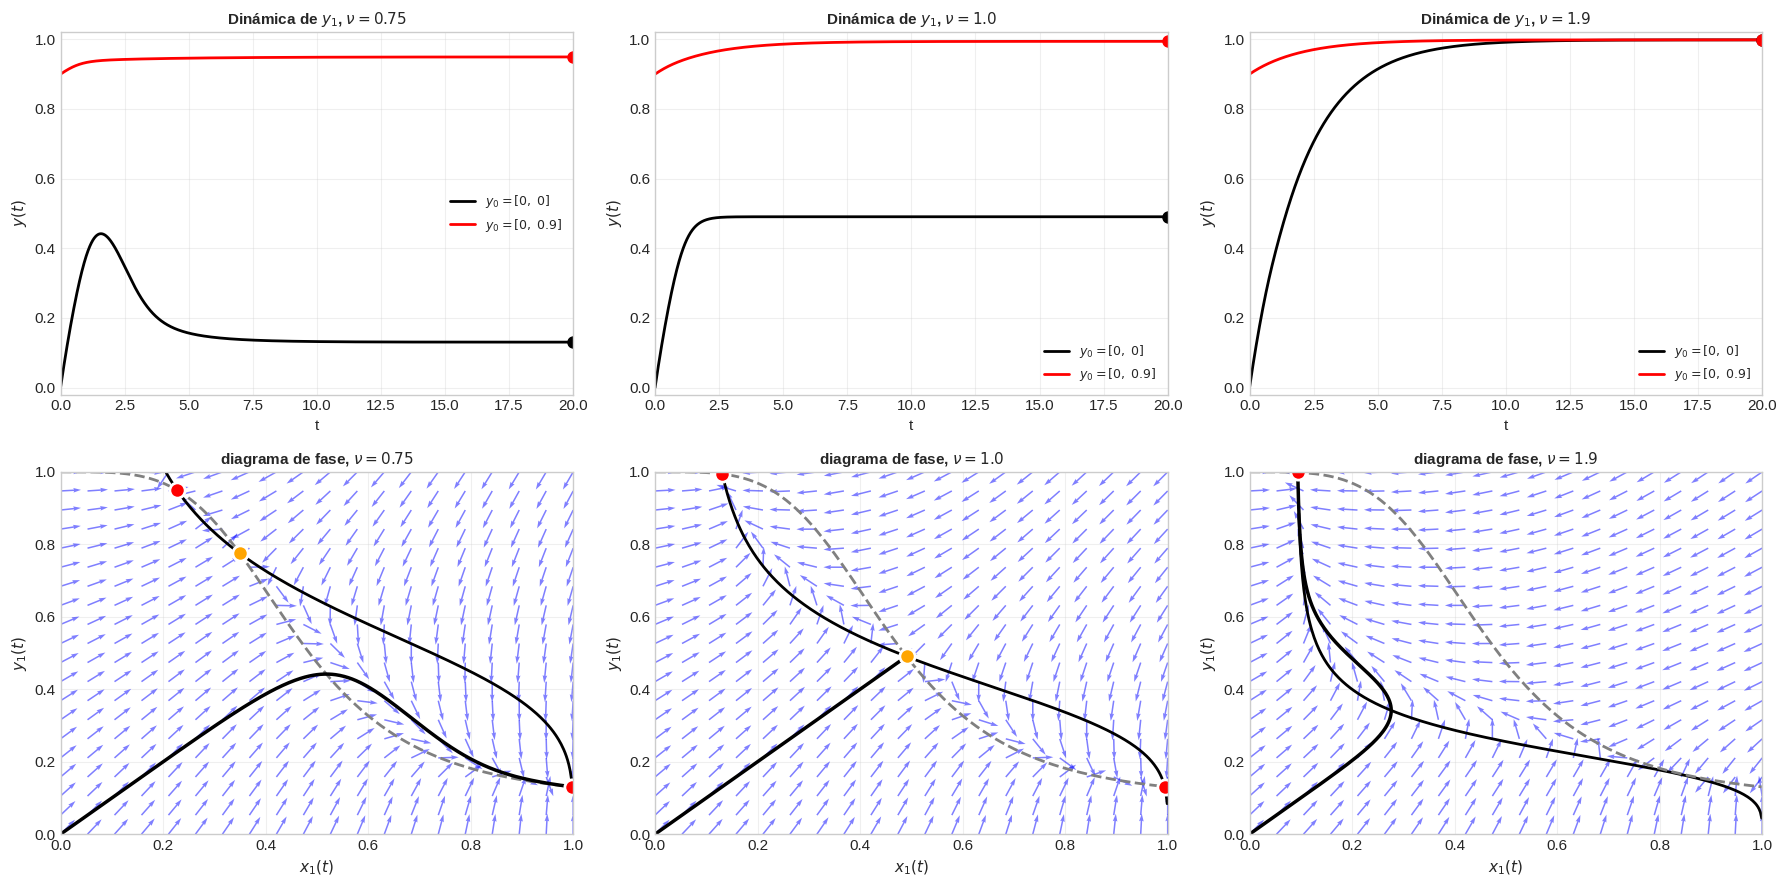

In [5]:
def plot_figura3(v_value, p_base=None):
    """
    Reproduce una columna de la Fig. 3: 
      Arriba: dinámica temporal y1(t) desde dos condiciones iniciales.
      Abajo: diagrama de fase con campo vectorial, nullclines y trayectoria.
    """
    if p_base is None:
        p_base = P_DEFAULT.copy()
    p = p_base.copy()
    p['v'] = v_value
    
    # --- Integración desde dos condiciones iniciales ---
    t1, x1a, y1a = simulate(p, 0.0, 0.0, t_max=20)
    t2, x1b, y1b = simulate(p, 0.0, 0.9, t_max=20)
    
    fig, axes = plt.subplots(2, 1, figsize=(7, 9))
    
    # ===== Panel superior: Dinámica temporal =====
    axes[0].plot(t1, y1a, color='k',  lw=2, label=r'$y_0 = [0,\;0]$')
    axes[0].plot(t2, y1b, color='red', lw=2, label=r'$y_0 = [0,\;0.9]$')
    axes[0].plot(t1[-1], y1a[-1], 'ko', ms=8)
    axes[0].plot(t2[-1], y1b[-1], 'ro', ms=8)
    axes[0].set_xlabel('t'); axes[0].set_ylabel(r'$y_1(t)$')
    axes[0].set_title(rf'Dinámica de $y_1$, $\nu = {v_value}$')
    axes[0].set_ylim(-0.02, 1.02); axes[0].set_xlim(0, 20)
    axes[0].legend(loc='best', framealpha=0.9)
    axes[0].grid(alpha=0.3)
    
    # ===== Panel inferior: Plano de fase =====
    ngrid = 25
    X1, Y1 = np.meshgrid(np.linspace(0, 1, ngrid), np.linspace(0, 1, ngrid))
    U = np.zeros_like(X1); V = np.zeros_like(Y1)
    for i in range(ngrid):
        for j in range(ngrid):
            dx, dy = model([X1[i, j], Y1[i, j]], 0, p)
            U[i, j] = dx; V[i, j] = dy
    N = np.sqrt(U**2 + V**2) + 1e-12
    Un, Vn = U / N, V / N
    axes[1].quiver(X1, Y1, Un, Vn, color='blue', alpha=0.55,
                   scale=25, width=0.003, headwidth=3)
    
    # Nullclines
    xg = np.linspace(0.001, 0.999, 400)
    yx = nullcline_X(xg, p)
    yy = nullcline_Y(xg, p)
    valid = np.isfinite(yx) & (yx >= 0) & (yx <= 1)
    axes[1].plot(xg[valid], yx[valid], 'k-',  lw=2, label=r'$dx_1/dt = 0$')
    axes[1].plot(xg, yy,               'gray', lw=2, linestyle='--', label=r'$dy_1/dt = 0$')
    
    # Trayectoria desde (0,0)
    axes[1].plot(x1a, y1a, color='k', lw=2.5)
    axes[1].plot(x1a[-1], y1a[-1], 'ko', ms=10)
    
    # Puntos fijos
    fps = find_fixed_points(p)
    for fp in fps:
        J = jacobian(*fp, p)
        det, tr = np.linalg.det(J), np.trace(J)
        color = 'red' if (det > 0 and tr < 0) else ('orange' if det < 0 else 'purple')
        axes[1].plot(fp[0], fp[1], 'o', color=color, ms=12, 
                     markeredgecolor='white', markeredgewidth=2)
    
    axes[1].set_xlabel(r'$x_1(t)$'); axes[1].set_ylabel(r'$y_1(t)$')
    axes[1].set_title(rf'Diagrama de fase, $\nu = {v_value}$')
    axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
    axes[1].legend(loc='best', framealpha=0.9)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Reproducir la Fig. 3 completa (3 valores de v en una fila)
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
v_values = [0.75, 1.0, 1.9]

for idx, v_val in enumerate(v_values):
    p = P_DEFAULT.copy(); p['v'] = v_val
    
    # --- Integración ---
    t1, x1a, y1a = simulate(p, 0.0, 0.0, t_max=20)
    t2, x1b, y1b = simulate(p, 0.0, 0.9, t_max=20)
    
    # --- Fila superior: dinámica temporal ---
    ax = axes[0, idx]
    ax.plot(t1, y1a, 'k-',  lw=2, label=r'$y_0 = [0,\;0]$')
    ax.plot(t2, y1b, 'r-',  lw=2, label=r'$y_0 = [0,\;0.9]$')
    ax.plot(t1[-1], y1a[-1], 'ko', ms=8)
    ax.plot(t2[-1], y1b[-1], 'ro', ms=8)
    ax.set_xlabel('t'); ax.set_ylabel(r'$y(t)$')
    ax.set_title(rf'Dinámica de $y_1$, $\nu = {v_val}$', fontsize=11)
    ax.set_ylim(-0.02, 1.02); ax.set_xlim(0, 20)
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)
    
    # --- Fila inferior: plano de fase ---
    ax = axes[1, idx]
    ngrid = 20
    X1, Y1 = np.meshgrid(np.linspace(0, 1, ngrid), np.linspace(0, 1, ngrid))
    U = np.zeros_like(X1); V = np.zeros_like(Y1)
    for i in range(ngrid):
        for j in range(ngrid):
            dx, dy = model([X1[i, j], Y1[i, j]], 0, p)
            U[i, j] = dx; V[i, j] = dy
    N = np.sqrt(U**2 + V**2) + 1e-12
    ax.quiver(X1, Y1, U/N, V/N, color='blue', alpha=0.5,
              scale=25, width=0.003, headwidth=3)
    
    xg = np.linspace(0.001, 0.999, 400)
    yx = nullcline_X(xg, p)
    yy = nullcline_Y(xg, p)
    valid = np.isfinite(yx) & (yx >= 0) & (yx <= 1)
    ax.plot(xg[valid], yx[valid], 'k-', lw=2)
    ax.plot(xg, yy, 'gray', lw=2, linestyle='--')
    ax.plot(x1a, y1a, 'k-', lw=2.5)
    ax.plot(x1a[-1], y1a[-1], 'ko', ms=10)
    
    for fp in find_fixed_points(p):
        J = jacobian(*fp, p)
        det, tr = np.linalg.det(J), np.trace(J)
        color = 'red' if (det > 0 and tr < 0) else ('orange' if det < 0 else 'purple')
        ax.plot(fp[0], fp[1], 'o', color=color, ms=11,
                markeredgecolor='white', markeredgewidth=2)
    
    ax.set_xlabel(r'$x_1(t)$'); ax.set_ylabel(r'$y_1(t)$')
    ax.set_title(rf'diagrama de fase, $\nu = {v_val}$', fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Paso 7: Optimización de Parámetros

## Motivación
En la práctica, los valores de los parámetros se estiman a partir de **datos experimentales con ruido**. La optimización busca el vector $\theta^*$ que minimiza el error cuadrático:

$$\theta^* = \arg\min_{\theta} \; \text{SSE}(\theta) = \arg\min_{\theta} \sum_{i=1}^{N} \left( y_i^{\text{exp}} - y_i^{\text{model}}(\theta) \right)^2$$

## Estrategia
1. **Generamos datos sintéticos** con parámetros "verdaderos" + ruido gaussiano.
2. **Fijamos todos los parámetros excepto $\nu$** para visualizar el paisaje de error.
3. **Exploramos $\nu$** y visualizamos el SSE.

En un problema real se usaría `scipy.optimize.minimize` con todos los parámetros, pero aquí priorizamos la **intuición visual**.

In [6]:
# --- Generación de datos sintéticos con ruido ---
np.random.seed(42)
P_TRUE = P_DEFAULT.copy()
P_TRUE['v'] = 1.0

t_exp = np.linspace(0, 15, 20)
X1_true, Y1_true = simulate(P_TRUE, 0.0, 0.9, t_max=15, n_points=1000)[1:]
# Interpolar a t_exp
Y1_exp = np.interp(t_exp, np.linspace(0, 15, 1000), Y1_true)
Y1_noisy = Y1_exp + np.random.normal(0, 0.03, size=len(t_exp))
Y1_noisy = np.clip(Y1_noisy, 0, 1)


def sse_for_v(v_guess):
    p = P_DEFAULT.copy()
    p['v'] = v_guess
    t_sim = np.linspace(0, 15, 1000)
    Y1_model = simulate(p, 0.0, 0.9, t_max=15, n_points=1000)[2]
    Y1_model_interp = np.interp(t_exp, t_sim, Y1_model)
    return np.sum((Y1_noisy - Y1_model_interp) ** 2), Y1_model_interp


def plot_optim(v_guess):
    sse, Y1_model = sse_for_v(v_guess)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(t_exp, Y1_noisy, color='red', s=60, zorder=3,
               label='Datos experimentales (con ruido)', edgecolor='white')
    ax.plot(t_exp, Y1_model, color='blue', lw=2.5, zorder=2,
            label=rf'Modelo ($\nu = {v_guess:.2f}$)')
    ax.set_xlabel('t'); ax.set_ylabel(r'$y_1(t)$')
    ax.set_title(rf'Ajuste del modelo — SSE = {sse:.4f}')
    ax.legend(loc='best'); ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout(); plt.show()


widgets.interact(plot_optim,
    v_guess=widgets.FloatSlider(value=0.5, min=0.1, max=3.0, step=0.05, description=r'$\nu$:')
)

interactive(children=(FloatSlider(value=0.5, description='$\\nu$:', max=3.0, min=0.1, step=0.05), Output()), _…

<function __main__.plot_optim(v_guess)>

# Paso 8: Análisis de Robustez — Bifurcación y Plasticidad

## Objetivo
Estudiar cómo cambia el comportamiento cualitativo del sistema al variar el parámetro de bifurcación $\nu$. En particular:

- ¿Cuántos atractores hay?
- ¿Cómo cambian sus valores?
- ¿Dónde ocurren las transiciones (bifurcaciones)?

## Diagrama de bifurcación
Barremos $\nu$ en un rango amplio y, para cada valor, calculamos los puntos fijos estables. Graficamos sus valores de $y_1^*$ contra $\nu$.

## Interpretación biológica
Este análisis revela la **plasticidad del sistema**: cuánto se puede perturbar el acoplamiento antes de que el sistema pierda la capacidad de recordar su estado (pierda biestabilidad y se vuelva monostable).

## Diagrama de bifurcación

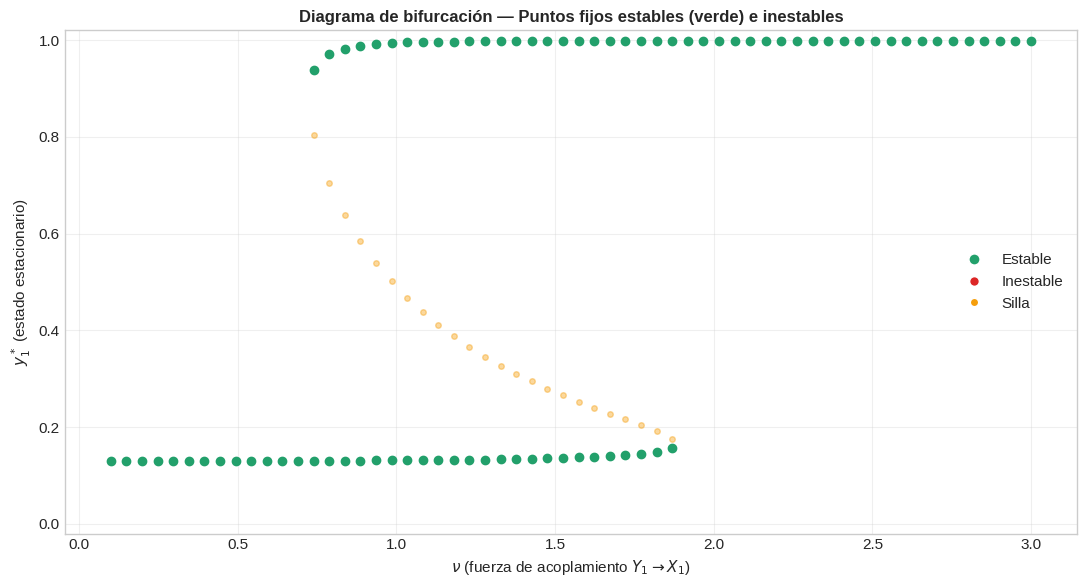

In [7]:
def bifurcation_diagram(p_base, v_range, n_points=60):
    """
    Para cada v en v_range, calcula puntos fijos y su estabilidad.
    Devuelve listas: (v, y1*, tipo) para graficar.
    """
    results = []
    for v in v_range:
        p = p_base.copy(); p['v'] = v
        fps = find_fixed_points(p)
        for fp in fps:
            J = jacobian(*fp, p)
            det, tr = np.linalg.det(J), np.trace(J)
            if det > 0 and tr < 0:
                stability = 'stable'
            elif det < 0:
                stability = 'saddle'
            else:
                stability = 'unstable'
            results.append((v, fp[1], fp[0], stability))
    return results


# Barrido
v_range = np.linspace(0.1, 3.0, 60)
results = bifurcation_diagram(P_DEFAULT, v_range)

fig, ax = plt.subplots(figsize=(11, 6))
for v, y1, x1, stab in results:
    if stab == 'stable':
        ax.plot(v, y1, 'o', color='#22a06b', ms=6)
    elif stab == 'unstable':
        ax.plot(v, y1, 'o', color='#dc2626', ms=5, alpha=0.5)
    else:  # saddle
        ax.plot(v, y1, 'o', color='#f59e0b', ms=4, alpha=0.4)

ax.set_xlabel(r'$\nu$ (fuerza de acoplamiento $Y_1 \to X_1$)')
ax.set_ylabel(r'$y_1^*$ (estado estacionario)')
ax.set_title(r'Diagrama de bifurcación — Puntos fijos estables (verde) e inestables')
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)

# Leyenda manual
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#22a06b', markersize=8, label='Estable'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#dc2626', markersize=7, label='Inestable'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f59e0b', markersize=6, label='Silla'),
]
ax.legend(handles=legend_elems, loc='center right')
plt.tight_layout()
plt.show()

# Análisis de Robustez Visual — Efecto de Perturbar $\nu$

## Objetivo
Cuantificar **visualmente** cómo responde el sistema cuando se perturba el parámetro de acoplamiento $\nu$.

## Paneles mostrados

1. **Dinámica temporal comparada**: cómo evoluciona $y_1(t)$ desde un mismo estado inicial cuando $\nu$ cambia.
2. **Plano de fase superpuesto**: nullclines y puntos fijos para ambos valores de $\nu$, con flechas que indican el desplazamiento.
3. **Atractores en función de $\nu$**: posiciones de los puntos fijos estables contra $\nu$, marcando los valores base y perturbado. Es un diagrama de bifurcación resaltado.

## Lectura de la robustez
- Si los atractores apenas se mueven al perturbar $\nu$ → **sistema robusto**.
- Si aparece o desaparece un atractor → **bifurcación**.
- Si los atractores cambian drásticamente de posición → **sistema plástico/sensible**.

In [8]:
def analisis_robustez_visual(v_base, delta_v, y0=0.9, t_max=20):
    """
    Muestra tres paneles comparando el sistema con ν = v_base y ν = v_base + Δν.
    """
    v_pert = v_base + delta_v
    p_base = P_DEFAULT.copy(); p_base['v'] = v_base
    p_pert = P_DEFAULT.copy(); p_pert['v'] = v_pert

    # --- 1. Dinámicas temporales ---
    t, x1_a, y1_a = simulate(p_base, 0.0, y0, t_max=t_max)
    _, x1_b, y1_b = simulate(p_pert, 0.0, y0, t_max=t_max)

    # --- 2. Puntos fijos y estabilidad ---
    def clasificar_fps(p):
        fps = find_fixed_points(p)
        estables, inestables, sillas = [], [], []
        for fp in fps:
            J = jacobian(*fp, p)
            det, tr = np.linalg.det(J), np.trace(J)
            if det > 0 and tr < 0:
                estables.append(fp)
            elif det < 0:
                sillas.append(fp)
            else:
                inestables.append(fp)
        return estables, inestables, sillas

    est_a, inest_a, sillas_a = clasificar_fps(p_base)
    est_b, inest_b, sillas_b = clasificar_fps(p_pert)

    # --- 3. Diagrama de bifurcación local (zoom) ---
    v_zoom = np.linspace(max(0.1, v_base - 1.0), v_base + 1.0, 60)
    resultados_bif = bifurcation_diagram(P_DEFAULT, v_zoom)

    # ============================================================
    # FIGURA: 3 paneles en fila
    # ============================================================
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

    # ---------- Panel A: Dinámicas temporales ----------
    ax = axes[0]
    ax.plot(t, y1_a, color='#16324f', lw=2.5,
            label=rf'$\nu = {v_base:.2f}$ (base)')
    ax.plot(t, y1_b, color='#dc2626', lw=2.5, linestyle='--',
            label=rf'$\nu = {v_pert:.2f}$ (perturbado)')
    ax.plot(t[-1], y1_a[-1], 'o', color='#16324f', ms=10, markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(t[-1], y1_b[-1], 'o', color='#dc2626', ms=10, markeredgecolor='white', markeredgewidth=1.5)
    ax.set_xlabel('t'); ax.set_ylabel(r'$y_1(t)$')
    ax.set_title(rf'A) Dinámica temporal desde $y_0 = {y0}$', fontsize=12)
    ax.set_ylim(-0.02, 1.02); ax.set_xlim(0, t_max)
    ax.legend(loc='best', framealpha=0.9, fontsize=10)
    ax.grid(alpha=0.3)

    # ---------- Panel B: Plano de fase superpuesto ----------
    ax = axes[1]
    # Nullclines base
    xg = np.linspace(0.001, 0.999, 400)
    yx_a = nullcline_X(xg, p_base)
    yy_a = nullcline_Y(xg, p_base)
    yx_b = nullcline_X(xg, p_pert)
    yy_b = nullcline_Y(xg, p_pert)

    valid_a = np.isfinite(yx_a) & (yx_a >= 0) & (yx_a <= 1)
    valid_b = np.isfinite(yx_b) & (yx_b >= 0) & (yx_b <= 1)

    ax.plot(xg[valid_a], yx_a[valid_a], color='#16324f', lw=2,
            label=rf'$dx_1/dt=0$ ($\nu = {v_base:.2f}$)')
    ax.plot(xg, yy_a, color='#16324f', lw=2, linestyle='--', alpha=0.6)
    ax.plot(xg[valid_b], yx_b[valid_b], color='#dc2626', lw=2, linestyle=':',
            label=rf'$dx_1/dt=0$ ($\nu = {v_pert:.2f}$)')
    ax.plot(xg, yy_b, color='#dc2626', lw=2, linestyle='-.', alpha=0.6)

    # Trayectorias
    ax.plot(x1_a, y1_a, color='#16324f', lw=2, alpha=0.7)
    ax.plot(x1_b, y1_b, color='#dc2626', lw=2, alpha=0.7, linestyle='--')

    # Puntos fijos base
    for fp in est_a:
        ax.plot(fp[0], fp[1], 'o', color='#22a06b', ms=14,
                markeredgecolor='#16324f', markeredgewidth=2, zorder=5)
    for fp in sillas_a:
        ax.plot(fp[0], fp[1], 's', color='#f59e0b', ms=11,
                markeredgecolor='#16324f', markeredgewidth=1.5, zorder=5)
    # Puntos fijos perturbado
    for fp in est_b:
        ax.plot(fp[0], fp[1], 'o', color='#22a06b', ms=14,
                markeredgecolor='#dc2626', markeredgewidth=2, zorder=5, alpha=0.55)
    for fp in sillas_b:
        ax.plot(fp[0], fp[1], 's', color='#f59e0b', ms=11,
                markeredgecolor='#dc2626', markeredgewidth=1.5, zorder=5, alpha=0.55)

    # Flechas de desplazamiento entre atractores correspondientes
    for fp_a in est_a:
        # Buscar el atractor más cercano en el sistema perturbado
        if est_b:
            dists = [np.hypot(fp_a[0]-fpb[0], fp_a[1]-fpb[1]) for fpb in est_b]
            j = int(np.argmin(dists))
            fp_b = est_b[j]
            if dists[j] > 0.02:
                ax.annotate('', xy=fp_b, xytext=fp_a,
                            arrowprops=dict(arrowstyle='->', color='purple',
                                            lw=2, alpha=0.7))

    ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$y_1$')
    ax.set_title(r'B) Plano de fase superpuesto', fontsize=12)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
    ax.grid(alpha=0.3)

    # ---------- Panel C: Diagrama de bifurcación local ----------
    ax = axes[2]
    for v, y1_, x1_, stab in resultados_bif:
        if stab == 'stable':
            ax.plot(v, y1_, 'o', color='#22a06b', ms=5, alpha=0.7)
        elif stab == 'unstable':
            ax.plot(v, y1_, 'o', color='#dc2626', ms=4, alpha=0.5)
        else:
            ax.plot(v, y1_, 'o', color='#f59e0b', ms=3.5, alpha=0.5)

    # Marcar el valor base
    ax.axvline(v_base, color='#16324f', lw=2.5, linestyle='-',
               label=rf'$\nu_{{base}} = {v_base:.2f}$')
    # Marcar el valor perturbado
    ax.axvline(v_pert, color='#dc2626', lw=2.5, linestyle='--',
               label=rf'$\nu_{{pert}} = {v_pert:.2f}$')

    ax.set_xlabel(r'$\nu$'); ax.set_ylabel(r'$y_1^*$ (atractor)')
    ax.set_title('C) Bifurcación local — ubicación de atractores', fontsize=12)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc='best', framealpha=0.9, fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ============================================================
    # DIAGNÓSTICO EN TEXTO
    # ============================================================
    print("=" * 70)
    print(f"DIAGNÓSTICO DE ROBUSTEZ")
    print("=" * 70)
    print(f"ν_base       = {v_base:.3f}   →  {len(est_a)} atractor(es) estable(s)")
    print(f"ν_perturbado = {v_pert:.3f}   →  {len(est_b)} atractor(es) estable(s)")
    print()
    print("Atractores base:")
    for fp in est_a:
        print(f"   (x1*, y1*) = ({fp[0]:.4f}, {fp[1]:.4f})")
    print("Atractores perturbados:")
    for fp in est_b:
        print(f"   (x1*, y1*) = ({fp[0]:.4f}, {fp[1]:.4f})")
    print()

    if len(est_a) != len(est_b):
        print("⚠️  Transición cualitativa (BIFURCACIÓN) detectada.")
        print("    El sistema cambió el número de atractores → NO robusto.")
    else:
        # Desplazamientos
        desplazamientos = []
        for fp_a in est_a:
            dists = [np.hypot(fp_a[0]-fpb[0], fp_a[1]-fpb[1]) for fpb in est_b]
            desplazamientos.append(min(dists))
        dmax = max(desplazamientos)
        print(f"✓  Mismo número de atractores.")
        print(f"   Desplazamiento máximo: {dmax:.4f}")
        if dmax < 0.05:
            print("   → Sistema ROBUSTO (atractores casi no se mueven).")
        elif dmax < 0.15:
            print("   → Sistema MODERADAMENTE SENSIBLE.")
        else:
            print("   → Sistema PLÁSTICO (atractores se desplazan mucho).")


widgets.interact(analisis_robustez_visual,
    v_base=widgets.FloatSlider(value=1.0, min=0.1, max=2.5, step=0.05, description=r'$\nu_{base}$:'),
    delta_v=widgets.FloatSlider(value=0.5, min=-1.0, max=1.0, step=0.05, description=r'$\Delta\nu$:'),
    y0=widgets.FloatSlider(value=0.9, min=0.0, max=1.0, step=0.05, description=r'$y_0$:')
)

interactive(children=(FloatSlider(value=1.0, description='$\\nu_{base}$:', max=2.5, min=0.1, step=0.05), Float…

<function __main__.analisis_robustez_visual(v_base, delta_v, y0=0.9, t_max=20)>

# Conclusiones y Observaciones Finales

## 1. Del diagrama a las ecuaciones
Partiendo de la red visual (Paso 1), derivamos un sistema de EDOs no lineales (Paso 2) que, tras aplicar conservación, se redujo de **4 a 2 dimensiones** (Paso 3).

## 2. El papel de la cooperatividad
Los términos de Hill con exponentes $\gamma_1, \gamma_2 > 1$ son **esenciales** para observar biestabilidad. Si $\gamma_1 = \gamma_2 = 1$, el sistema se vuelve linealmente estable y **pierde la capacidad de conmutar**.

## 3. Bifurcación controlada por $\nu$
El parámetro $\nu$ controla la "fuerza" del acoplamiento $Y_1 \to X_1$:

| Rango de $\nu$ | Comportamiento |
|---|---|
| $\nu < 0.7$ | Biestable (dos atractores) |
| $0.7 < \nu < 1.5$ | Biestable con asimetría creciente |
| $\nu > 1.5$ | Monostable (un único atractor) |

## 4. Dependencia de condiciones iniciales
Confirmamos numéricamente que el estado final **depende del pasado** (histéresis), un sello distintivo de las redes biestables.

## 5. Relevancia biológica
Este tipo de red es un **motivo recurrente** en biología: interruptores de decisión celular, memoria epigenética, ciclos celulares irreversibles, y diferenciación de linajes.

## Sugerencias para el estudiante
- **Extensión 1:** Reemplaza el término $x_1^{\gamma_2}$ en el Hill de Y por $(x_1/K)^\gamma$ para explorar el efecto de la afinidad.
- **Extensión 2:** Añade un término de **degradación basal** $\delta \cdot x_1$ al modelo y verifica si la biestabilidad persiste.
- **Extensión 3:** Convierte $\nu$ en una variable dinámica lenta (como en la Sección 2.9) y estudia el sistema híbrido de 3D.
- **Extensión 4:** Implementa una red de **3 nodos** con retroalimentación cíclica y compara el espacio de parámetros.

# Experimento  sugerido

Probar estas tres configuraciones y comparen los diagnósticos:

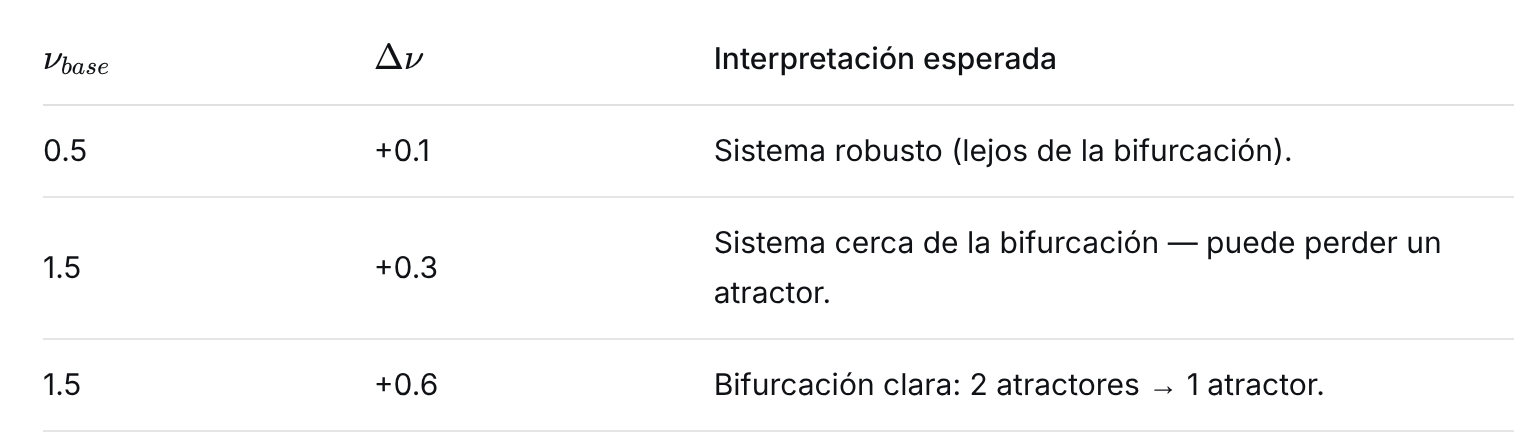

Al observar la longitud de las flechas moradas en el Panel B,  podran "ver" la robustez antes de leer el diagnóstico numérico.